# **MobileNet**

In [1]:
# Import NumPy for numerical operations (arrays, matrices, etc.)
import numpy as np

# Import matplotlib for data visualization (like plotting images, graphs)
import matplotlib.pyplot as plt

# Import pre-trained MobileNetV2 model (Transfer Learning)
from tensorflow.keras.applications import MobileNetV2

# Import layers and model building utilities from Keras
from tensorflow.keras import layers, models

# Import CIFAR-10 dataset (contains 10 classes of images like cats, dogs, cars, etc.)
from tensorflow.keras.datasets import cifar10

# Utility to convert labels into one-hot encoded format
from tensorflow.keras.utils import to_categorical

# Import PIL for image processing (resize, load, convert images)
from PIL import Image

In [2]:
# Load the CIFAR-10 dataset
# It returns 4 arrays:
# x_train -> training images
# y_train -> training labels
# x_test  -> testing images
# y_test  -> testing labels
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 254s 1us/step


In [3]:
# Print the shape (dimensions) of training images
# Expected: (50000, 32, 32, 3)
# Meaning:
# 50000 images, each of size 32x32 pixels, with 3 color channels (RGB)
print("Train images:", x_train.shape)

Train images: (50000, 32, 32, 3)


In [4]:
# Print the shape of test images
# Expected: (10000, 32, 32, 3)
# Meaning:
# 10000 images used for testing the model
print("Test images:", x_test.shape)

Test images: (10000, 32, 32, 3)


In [5]:
# Define class names corresponding to label values (0–9)
# CIFAR-10 has 10 categories of objects
classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

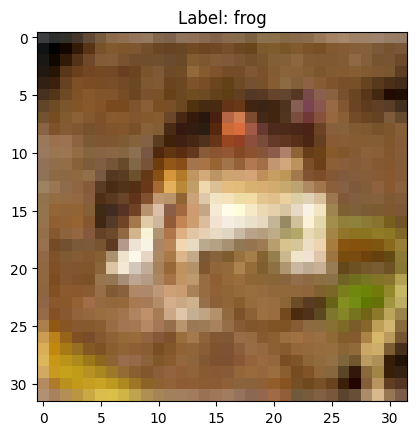

In [9]:
# Display the first image from the training dataset
# x_train[0] is a 32x32 RGB image (3 channels)
plt.imshow(x_train[0])

# Set the title of the image using its label
# y_train[0] gives something like [3], so we use [0] again to get the actual value → 3
# Then we map it to class name using the 'classes' list → 'cat'
plt.title(f"Label: {classes[y_train[0][0]]}")

# Show the image with title on screen
plt.show()

In [10]:
# Normalize pixel values from range [0, 255] → [0, 1]
# This helps the model train faster and more efficiently
# because neural networks perform better with smaller, scaled values
x_train = x_train / 255.0
x_test  = x_test  / 255.0

In [11]:
# Convert labels into one-hot encoded format
# Example: class '3' → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# This is required for multi-class classification using softmax
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [12]:
# Print shape after preprocessing (shape remains same for images)
# Still: (50000, 32, 32, 3)
# Note: Images are NOT resized yet (important for models like MobileNetV2)
print("After preprocess:", x_train.shape)

After preprocess: (50000, 32, 32, 3)


In [13]:
# Split the last 10,000 samples from training data to create a validation set

# Take images from index 40000 to end → validation images
x_val = x_train[40000:]

In [14]:
# Take corresponding labels for validation
y_val = y_train[40000:]

In [15]:
# Keep only first 40,000 images for actual training
x_train = x_train[:40000]

# Keep corresponding labels for training
y_train = y_train[:40000]

In [16]:
# Print shapes to verify the split
# Train: (40000, 32, 32, 3)
print("Train:", x_train.shape)

# Validation: (10000, 32, 32, 3)
print("Val:  ", x_val.shape)

Train: (40000, 32, 32, 3)
Val:   (10000, 32, 32, 3)


In [17]:
# Build a Sequential CNN model
model = models.Sequential([

    # Resize input images from 32x32 → 224x224
    # This allows using larger convolution kernels (like 11x11)
    layers.Resizing(224, 224, input_shape=(32, 32, 3)),

    # -------- Block 1 --------
    # Apply 96 filters of size 11x11 with stride 4
    # Large kernel captures high-level spatial features quickly
    layers.Conv2D(96, (11,11), strides=4, activation='relu'),

    # Downsample feature maps using MaxPooling
    layers.MaxPooling2D((3,3), strides=2),

    # -------- Block 2 --------
    # Apply 256 filters with 5x5 kernel
    # 'same' padding keeps spatial size unchanged
    layers.Conv2D(256, (5,5), padding='same', activation='relu'),

    # Further downsampling
    layers.MaxPooling2D((3,3), strides=2),

    # -------- Block 3 --------
    # Deeper feature extraction with 384 filters
    layers.Conv2D(384, (3,3), padding='same', activation='relu'),

    # -------- Block 4 --------
    # Another convolution layer (same depth)
    layers.Conv2D(384, (3,3), padding='same', activation='relu'),

    # -------- Block 5 --------
    # Reduce filters back to 256
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),

    # Final pooling layer
    layers.MaxPooling2D((3,3), strides=2),

    # Flatten 2D feature maps → 1D vector
    layers.Flatten(),   # 2048

    # Fully connected layer (like traditional neural network)
    layers.Dense(4096, activation='relu'),

    # Dropout randomly disables 50% neurons → prevents overfitting
    layers.Dropout(0.5),

    # Another dense layer
    layers.Dense(4096, activation='relu'),
    layers.Dropout(0.5),

    # Output layer with 10 neurons (for 10 classes)
    # Softmax converts output into probabilities
    layers.Dense(10, activation='softmax')
])

# Print model architecture (layers, parameters, output shapes)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,787,978 (178.48 MB)

 Trainable params: 46,787,978 (178.48 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Compile the model (configure how the model will learn)

model.compile(
    # Optimizer defines how weights are updated during training
    # 'adam' is an adaptive optimizer → fast and widely used for deep learning
    optimizer='adam',

    # Loss function measures how wrong the predictions are
    # 'categorical_crossentropy' is used for multi-class classification
    # (because labels are one-hot encoded)
    loss='categorical_crossentropy',

    # Metric to evaluate model performance
    # 'accuracy' calculates percentage of correct predictions
    metrics=['accuracy']
)

In [19]:
# Train the model on training data

history = model.fit(
    x_train, y_train,          # Training data (features and labels)

    epochs=5,                  # Number of times the model will see the entire dataset
                               # 1 epoch = full pass over all training samples

    batch_size=64,             # Number of samples processed before updating weights
                               # Smaller batch → more updates, larger batch → faster computation

    validation_data=(x_val, y_val)  # Validation data used to evaluate model after each epoch
                                    # Helps monitor overfitting/underfitting
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.2731 - loss: 1.9566 - val_accuracy: 0.3885 - val_loss: 1.6847
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.4346 - loss: 1.5391 - val_accuracy: 0.4865 - val_loss: 1.3928
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.4975 - loss: 1.3840 - val_accuracy: 0.5575 - val_loss: 1.2490
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.5447 - loss: 1.2747 - val_accuracy: 0.5782 - val_loss: 1.2024
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.5733 - loss: 1.1969 - val_accuracy: 0.5933 - val_loss: 1.1479


In [20]:
# Evaluate the trained model on unseen test data

# model.evaluate returns:
# test_loss → how much error the model makes on test data
# test_acc  → accuracy on test data (percentage of correct predictions)
test_loss, test_acc = model.evaluate(x_test, y_test)

# Print test loss (rounded to 4 decimal places)
print(f"Test Loss:     {test_loss:.4f}")

# Print test accuracy (rounded to 4 decimal places)
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5930 - loss: 1.1480
Test Loss:     1.1480
Test Accuracy: 0.5930


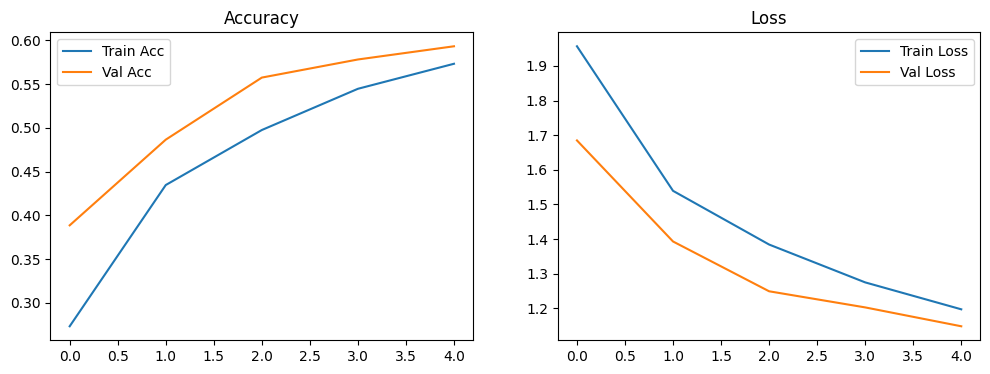

In [21]:
# plot accuracy and loss curves
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

Saving OIP.jpg to OIP.jpg


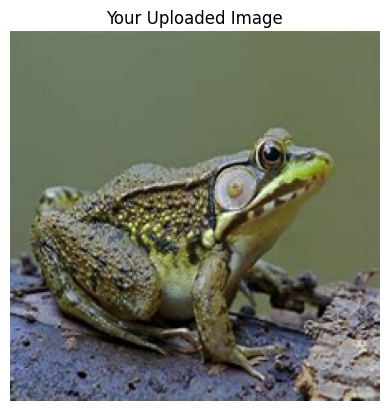

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Class: ship
Confidence:      41.41%


In [25]:
# Import file upload utility (used in Google Colab)
from google.colab import files

# Upload an image file from local system
uploaded = files.upload()

# Get the file path (name of uploaded file)
img_path = list(uploaded.keys())[0]

# -------- Image Loading & Preprocessing --------

# Open the image and convert to RGB format (ensures 3 color channels)
img = Image.open(img_path).convert('RGB')

# Resize image to 224x224 (required for this model input)
img = img.resize((224, 224))

# Convert image to NumPy array and normalize pixel values [0,255] → [0,1]
img_array = np.array(img) / 255.0

# Add batch dimension → shape becomes (1, 224, 224, 3)
# Model expects input in batches
img_array = np.expand_dims(img_array, 0)

# -------- Display Image --------

# Show the uploaded image
plt.imshow(img)

# Set title
plt.title("Your Uploaded Image")

# Hide axis (for cleaner visualization)
plt.axis('off')

# Display the image
plt.show()

# -------- Prediction --------

# Predict probabilities for each class (output shape: [1, 10])
pred = model.predict(img_array)

# Get index of highest probability → predicted class
pred_class = np.argmax(pred)

# Get confidence score (highest probability × 100)
confidence = np.max(pred) * 100

# Print predicted class name using class list
print(f"Predicted Class: {classes[pred_class]}")

# Print confidence percentage
print(f"Confidence:      {confidence:.2f}%")

In [26]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:00



image 1/1 /content/avengers (1).jpg: 384x640 6 persons, 3 cars, 1 bus, 3 trucks, 1 frisbee, 64.8ms
Speed: 2.1ms preprocess, 64.8ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


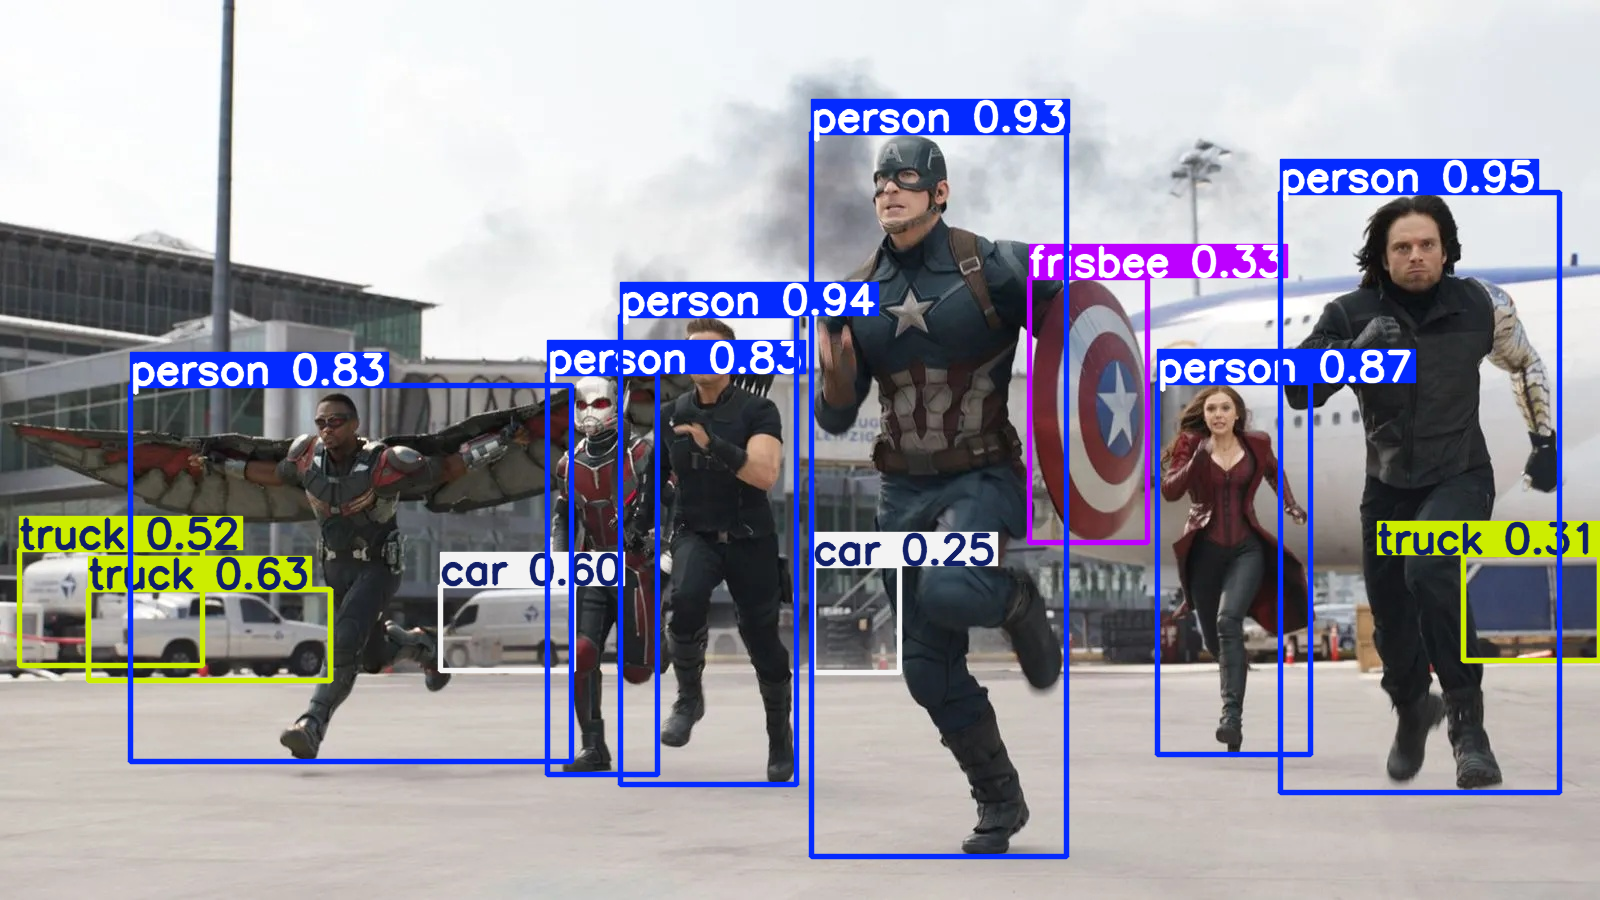

In [30]:
from ultralytics import YOLO

# Small model load
model = YOLO("yolo26s.pt")  # first time automatic download

# object detection on image
results = model("/content/avengers (1).jpg")

# Show result
results[0].show()# for video detection
#results = model("path/to/video.mp4")
#for r in results:
    #r.show()